In [ ]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# Style
sns.set(style="whitegrid")

In [ ]:
# ==============================
# LOAD DATASET
# ==============================
df_heart = pd.read_csv("heart.csv")

# Preview
df_heart.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [ ]:
# ==============================
# DATA UNDERSTANDING
# ==============================

print("Shape:", df_heart.shape)

Shape: (1025, 14)


In [ ]:
print("\nInfo:\n")
print(df_heart.info())


Info:

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   str    
 2   chest_pain_type                1025 non-null   str    
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   str    
 6   rest_ecg                       1025 non-null   str    
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   str    
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   str    
 11  vessels_colored_by_flourosopy  1025 non-null   str    
 12  thalassemia                    1025 non-null   str 

In [ ]:
print("\nMissing Values:\n")
print(df_heart.isnull().sum())


Missing Values:

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64


In [ ]:
print("\nStatistical Summary:\n")
print(df_heart.describe())


Statistical Summary:

               age  resting_blood_pressure  cholestoral  Max_heart_rate  \
count  1025.000000             1025.000000   1025.00000     1025.000000   
mean     54.434146              131.611707    246.00000      149.114146   
std       9.072290               17.516718     51.59251       23.005724   
min      29.000000               94.000000    126.00000       71.000000   
25%      48.000000              120.000000    211.00000      132.000000   
50%      56.000000              130.000000    240.00000      152.000000   
75%      61.000000              140.000000    275.00000      166.000000   
max      77.000000              200.000000    564.00000      202.000000   

           oldpeak       target  
count  1025.000000  1025.000000  
mean      1.071512     0.513171  
std       1.175053     0.500070  
min       0.000000     0.000000  
25%       0.000000     0.000000  
50%       0.800000     1.000000  
75%       1.800000     1.000000  
max       6.200000     1.0000

In [ ]:
# ==============================
# DATA CLEANING
# ==============================

# Remove duplicates
df_heart = df_heart.drop_duplicates()

# Check again
print("After cleaning shape:", df_heart.shape)

df_heart.columns = df_heart.columns.str.strip().str.lower()
df_heart.head()

After cleaning shape: (302, 14)


,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [ ]:
# ==============================
# DATA PREPARATION
# ==============================

X = df_heart.drop("target", axis=1)
y = df_heart["target"]

# Convert categorical columns to numeric
X = pd.get_dummies(X, drop_first=True)

print("Before SMOTE:", y.value_counts().to_dict())

# Apply SMOTE first (before scaling)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

# Then scale the resampled data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

print("Shape after encoding:", X_resampled.shape)

Before SMOTE: {1: 164, 0: 138}
After SMOTE: {0: 164, 1: 164}
Shape after encoding: (328, 22)


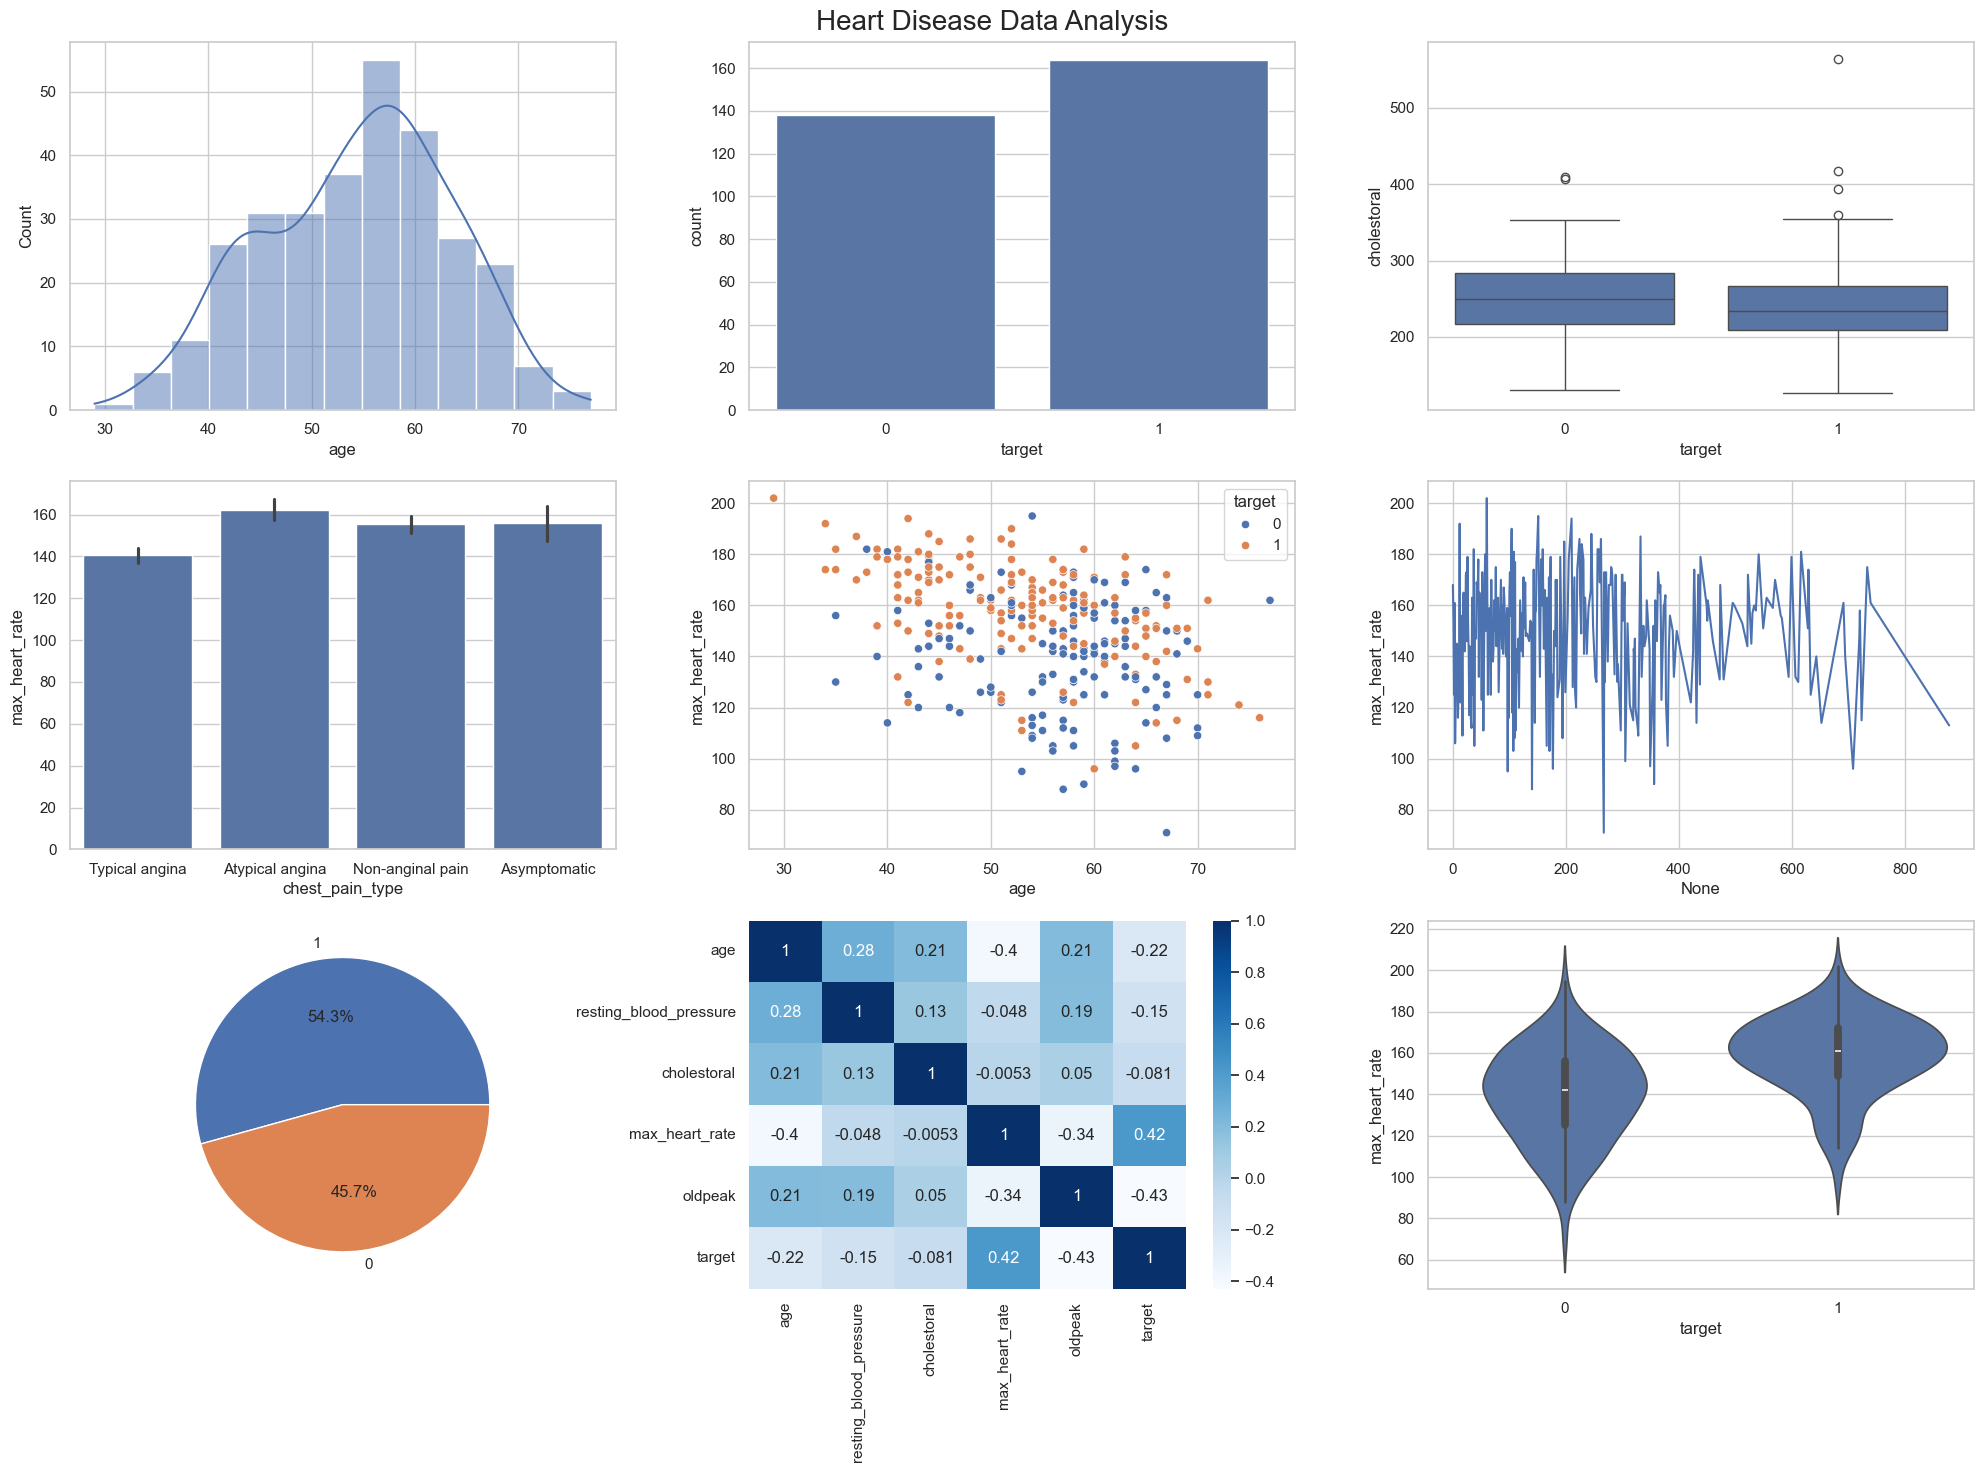

In [ ]:
# ==============================
# VISUALIZATION
# ==============================

plt.figure(figsize=(20, 15))
plt.suptitle("Heart Disease Data Analysis", fontsize=20)

# 1. Histogram
plt.subplot(3, 3, 1)
sns.histplot(df_heart["age"], kde=True)

# 2. Countplot
plt.subplot(3, 3, 2)
sns.countplot(x="target", data=df_heart)

# 3. Boxplot
plt.subplot(3, 3, 3)
sns.boxplot(x="target", y="cholestoral", data=df_heart)

# 4. Barplot
plt.subplot(3, 3, 4)
sns.barplot(x="chest_pain_type", y="max_heart_rate", data=df_heart)

# 5. Scatterplot
plt.subplot(3, 3, 5)
sns.scatterplot(x="age", y="max_heart_rate", hue="target", data=df_heart)

# 6. Lineplot
plt.subplot(3, 3, 6)
sns.lineplot(x=df_heart.index, y="max_heart_rate", data=df_heart)

# 7. Pie Chart
plt.subplot(3, 3, 7)
df_heart["target"].value_counts().plot.pie(autopct="%1.1f%%")

# 8. Heatmap
plt.subplot(3, 3, 8)
df_encoded = pd.get_dummies(df_heart, drop_first=True)
sns.heatmap(df_heart.select_dtypes(include=np.number).corr(), annot=True, cmap="Blues")

# 9. Violin Plot
plt.subplot(3, 3, 9)
sns.violinplot(x="target", y="max_heart_rate", data=df_heart)

plt.tight_layout()
plt.show()

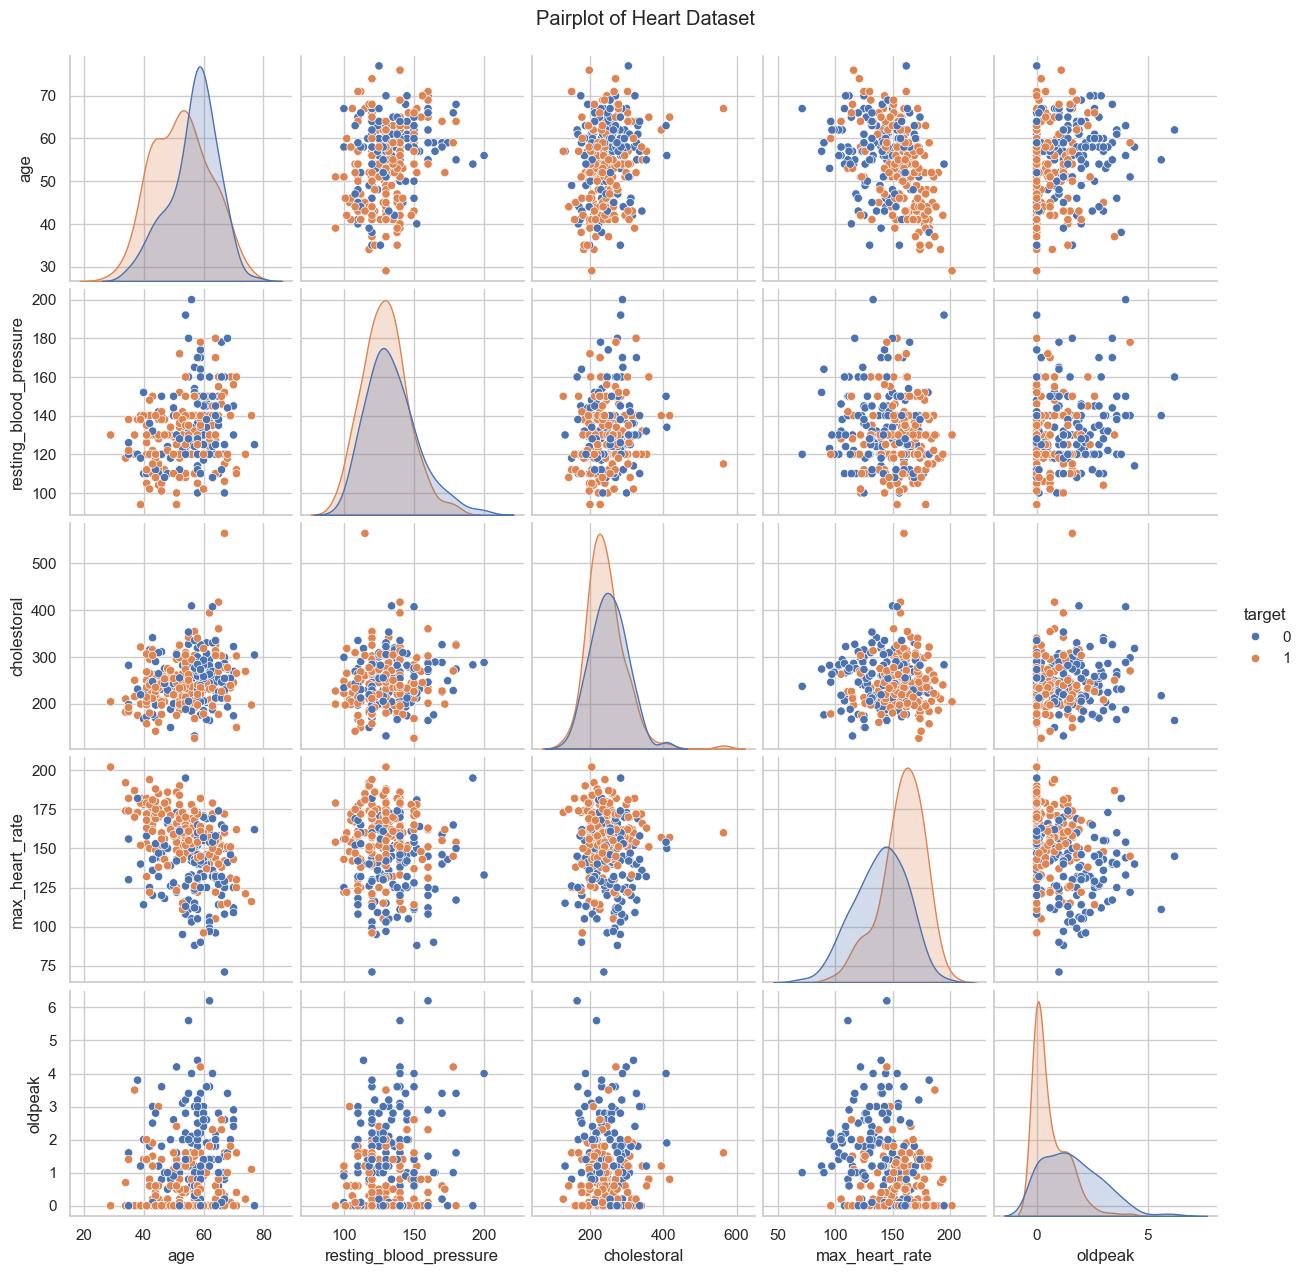

In [ ]:
# ==============================
# EXTRA VISUALIZATION - PAIRPLOT
# ==============================

sns.pairplot(df_heart, hue="target")
plt.suptitle("Pairplot of Heart Dataset", y=1.02)
plt.show()

In [ ]:
# ==============================
# MACHINE LEARNING - LOGISTIC REGRESSION
# ==============================

# SMOTE wale resampled data use karo
X_resampled_df = pd.DataFrame(
    X_resampled,
    columns=pd.get_dummies(df_heart.drop("target", axis=1), drop_first=True).columns,
)

y_final = pd.Series(y_resampled)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled_df, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(scaler, "heart_scaler.pkl")

# Logistic Regression
lr_heart = LogisticRegression(max_iter=3000)
lr_heart.fit(X_train, y_train)

y_pred_lr = lr_heart.predict(X_test)

joblib.dump(lr_heart, "heart_model.pkl")

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8939393939393939


In [ ]:
# ==============================
# MACHINE LEARNING - RANDOM FOREST
# ==============================

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

joblib.dump(rf, "heart_rf_model.pkl")

print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, pred_rf))

Logistic Regression: 0.8939393939393939
Random Forest: 0.8484848484848485


In [ ]:
# ==============================
# MODEL EVALUATION
# ==============================

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.88      0.91      0.90        33

    accuracy                           0.89        66
   macro avg       0.89      0.89      0.89        66
weighted avg       0.89      0.89      0.89        66



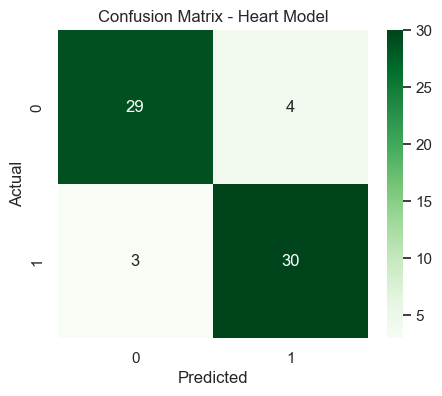

In [ ]:
# ==============================
# CONFUSION MATRIX
# ==============================

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Heart Model")
plt.show()